# 02 · Planting-date sweep

Compare maize potential grain yield across seven planting dates at Gainesville using the same 1982 weather.

## You will learn

- Build a `Simulation` from a copied FileX.
- Use controls to remove water and nitrogen limitations.
- Run a planting-date sweep and compare grain yield in a table and plot.

In [1]:
LESSON = "02_planting_dates"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load tools for dates, tables and inline plots.

In [3]:
# Load tools for dates, tables and inline plots.
from datetime import date, timedelta
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
print("Tools ready: dates, tables and plots.")

Tools ready: dates, tables and plots.


Select the copied stock inputs in `runs/` to keep each execution fresh.

In [4]:
# Select the copied FileX, weather and soil files.
inputs = {
    "filex": RUNS / "UFGA8201.MZX",
    "weather": RUNS / "UFGA8201.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
print("Inputs:", ", ".join(inputs[key].relative_to(HERE).as_posix()
                          for key in ("filex", "weather", "soil")))

Inputs: runs/UFGA8201.MZX, runs/UFGA8201.WTH, runs/SOIL.SOL


🌱 Crop idea  
Stock treatment 1 grows Gainesville maize cultivar McCurdy 84aa (`IB0035`).
With water and nitrogen simulation off, weather and crop development still affect potential yield.

Build and check a `Simulation` with water and nitrogen off for potential production.

In [5]:
# Disable water and nitrogen simulation, then check treatment 1.
experiment = {"treatments": {1: {"controls": {"water": "N", "nitrogen": "N"}}}}
sim = dl.Simulation(**inputs, treatment=1, management=experiment)
problems = sim.check(verbose=False)
print("Problems:", problems)

Problems: []


🐍 Python idea  
A dictionary pairs a name with a value, such as `"water": "N"`.
`**inputs` passes those entries as named arguments; `Problems: []` means the check found none.

Run the base Simulation and read planting date (`PDAT`) and grain yield (`HWAM`, kg/ha).

In [6]:
# Run the stock planting date and show its potential yield.
base_result = sim.run()
base_summary = dl.to_dataframe(dl.read_summary(base_result.run_dir))
base_summary[["TRNO", "PDAT", "HWAM"]]

,TRNO,PDAT,HWAM
0,1,1982-02-26,11859


Build seven dates 14 days apart from stock PDATE `82057` (26 February 1982), keeping all other planting details fixed.

In [7]:
# Supply complete stock planting details for each labelled date.
planting = {
    "method": "S",
    "distribution": "R",
    "population": 7.2,
    "emergence_population": 7.2,
    "row_spacing": 61,
    "row_direction": 0,
    "depth": 7,
    "sprout_length": 0,
}
first_date = date(1982, 2, 26)
spacing_days = 14
dates = [(first_date + timedelta(days=spacing_days * i)).isoformat() for i in range(7)]
factors = {"planting": {day: dict(planting, date=day) for day in dates}}
dl.to_dataframe([{"Planting date": day} for day in factors["planting"]])

,Planting date
0,1982-02-26
1,1982-03-12
2,1982-03-26
3,1982-04-09
4,1982-04-23
5,1982-05-07
6,1982-05-21


🐍 Python idea  
`range(7)` counts from 0 through 6; `timedelta` moves a date, and `dict(planting, date=day)` adds it to a copy of the details.
A sweep replaces the whole planting section: both populations are in plants/m²; row spacing, depth and sprout length are in cm; row direction is in degrees from north; `S`/`R` mean seed/rows.

Run the sweep and show all eight Summary rows: one base plus seven labelled planting dates.

In [8]:
# Run the planting-date sweep and show actual dates and grain yields.
rows = dl.run_sweep(**inputs, treatments=[1], management=experiment, factors=factors)
results = dl.to_dataframe(rows)
results[["scenario", "planting", "PDAT", "HWAM"]]

,scenario,planting,PDAT,HWAM
0,base,NaN,1982-02-26,11859
1,1982-02-26,1982-02-26,1982-02-26,11859
2,1982-03-12,1982-03-12,1982-03-12,9254
3,1982-03-26,1982-03-26,1982-03-26,12321
4,1982-04-09,1982-04-09,1982-04-09,9958
5,1982-04-23,1982-04-23,1982-04-23,11640
6,1982-05-07,1982-05-07,1982-05-07,10217
7,1982-05-21,1982-05-21,1982-05-21,7775


🌱 Crop idea  
The yield does not fall smoothly with later planting: it zig-zags because each sowing meets different 1982 weather during its season, with water and N off.
This one season is not a planting recommendation for all years.

Filter the extra `base` row, whose empty factor label repeats the first date and yield, so the plot compares seven dates once each.

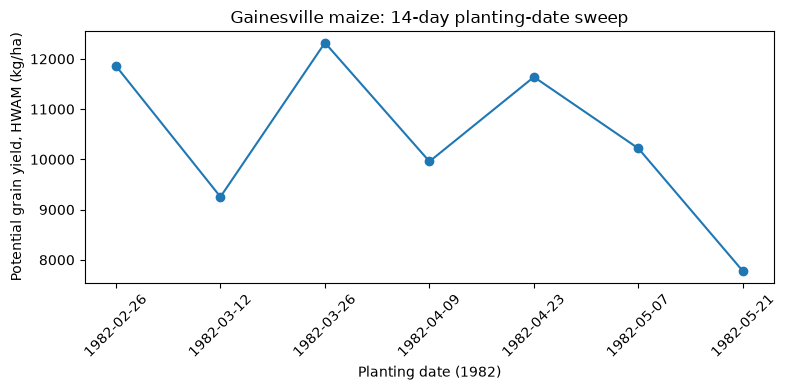

In [9]:
# Plot only the labelled planting-date scenarios.
comparison = results.loc[results["scenario"] != "base", ["planting", "HWAM"]].copy()
ax = comparison.plot(x="planting", y="HWAM", marker="o", legend=False, figsize=(8, 4))
ax.set(xlabel="Planting date (1982)", ylabel="Potential grain yield, HWAM (kg/ha)",
       title="Gainesville maize: 14-day planting-date sweep")
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

## Your turn

Run a new seven-date sweep and compare its table and plot.

Hint: edit `spacing_days` at the top of this cell (start with 21), then run this cell.

,planting,PDAT,HWAM
1,1982-02-26,1982-02-26,11859
2,1982-03-19,1982-03-19,12521
3,1982-04-09,1982-04-09,9958
4,1982-04-30,1982-04-30,9962
5,1982-05-21,1982-05-21,7775
6,1982-06-11,1982-06-11,9657
7,1982-07-02,1982-07-02,9589


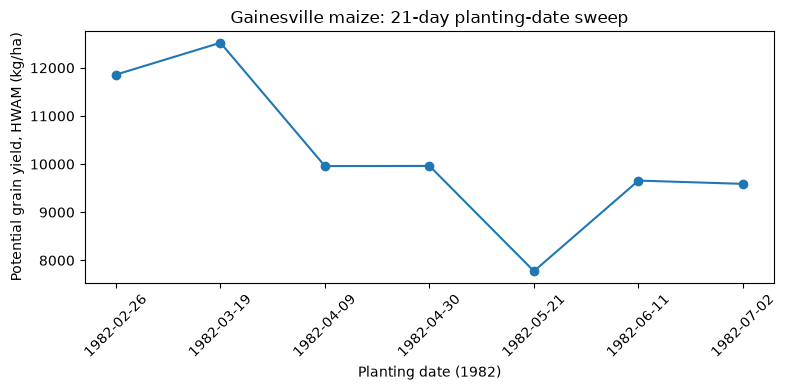

In [10]:
spacing_days = 21
# Rebuild and run the exercise, then show its table and plot.
exercise_inputs = {
    "filex": RUNS / "UFGA8201.MZX",
    "weather": RUNS / "UFGA8201.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
exercise_experiment = {"treatments": {1: {"controls": {"water": "N", "nitrogen": "N"}}}}
exercise_planting = {
    "method": "S",
    "distribution": "R",
    "population": 7.2,
    "emergence_population": 7.2,
    "row_spacing": 61,
    "row_direction": 0,
    "depth": 7,
    "sprout_length": 0,
}
first_date = date(1982, 2, 26)
exercise_dates = [(first_date + timedelta(days=spacing_days * i)).isoformat() for i in range(7)]
exercise_factors = {"planting": {day: dict(exercise_planting, date=day) for day in exercise_dates}}
exercise_rows = dl.run_sweep(**exercise_inputs, treatments=[1],
                             management=exercise_experiment, factors=exercise_factors)
exercise_results = dl.to_dataframe(exercise_rows)
exercise_comparison = exercise_results.loc[
    exercise_results["scenario"] != "base", ["planting", "PDAT", "HWAM"]
].copy()
display(exercise_comparison)
ax = exercise_comparison.plot(x="planting", y="HWAM", marker="o", legend=False, figsize=(8, 4))
ax.set(xlabel="Planting date (1982)", ylabel="Potential grain yield, HWAM (kg/ha)",
       title=f"Gainesville maize: {spacing_days}-day planting-date sweep")
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

## Recap

- A `Simulation` combines one FileX treatment with inputs and controls.
- Water and nitrogen controls set to `"N"` remove those limits for this potential-production comparison.
- A sweep returns a base row plus labelled scenarios; `HWAM` compares grain yield in kg/ha.

Next: [Comparing cultivars and maturity groups](../03_cultivars/lesson.ipynb).